In [ ]:
#This space is for installing any and/or all required libraries

In [6]:
"""
Full end-to-end notebook (LightGBM) starting from scratch:
- Load data
- Validate date range (2024-10-01 -> 2025-09-30 expected)
- Compute biller-level aggregates
- Fit GMM clustering (on training period only)
- Assign clusters to all billers
- Auto-label clusters as one of:
'HighValue_HighAmount', 'HighValue_LowAmount', 'LowValue_HighAmount', 'LowValue_LowAmount'
(based on cluster centroid position relative to medians)
- Create daily features (time, lags, rolling)
- Train LightGBM models:
Model A: txn_value (count)
Model B: txn_amount (amount) — uses Model A prediction as a feature
- Visualizations: cluster PCA, heatmap, radar charts, actual vs predicted, scatter, per-biller time-series
- Metrics: MAE, RMSE


Save models and cluster summary.
"""

"\nFull end-to-end notebook (LightGBM) starting from scratch:\n- Load data\n- Validate date range (2024-10-01 -> 2025-09-30 expected)\n- Compute biller-level aggregates\n- Fit GMM clustering (on training period only)\n- Assign clusters to all billers\n- Auto-label clusters as one of:\n'HighValue_HighAmount', 'HighValue_LowAmount', 'LowValue_HighAmount', 'LowValue_LowAmount'\n(based on cluster centroid position relative to medians)\n- Create daily features (time, lags, rolling)\n- Train LightGBM models:\nModel A: txn_value (count)\nModel B: txn_amount (amount) — uses Model A prediction as a feature\n- Visualizations: cluster PCA, heatmap, radar charts, actual vs predicted, scatter, per-biller time-series\n- Metrics: MAE, RMSE\n\n\nSave models and cluster summary.\n"

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import joblib

In [15]:
# ------------------
# CONFIG
# ------------------
CSV_PATH = 'India_upi_like_biller_realistic.csv' # change if needed
MODEL_DIR = 'models_lightgbm_v2'
N_CLUSTERS = 4
TEST_DAYS = 90
LOOKBACK_DAYS = 180
RANDOM_STATE = 42
os.makedirs(MODEL_DIR, exist_ok=True)

In [16]:
# -----------------------------
# LOAD + VALIDATE
# -----------------------------


df = pd.read_csv(CSV_PATH, parse_dates=['txn_date'])
df['biller_id'] = df['biller_id'].astype(str)
df = df.sort_values(['biller_id','txn_date']).reset_index(drop=True)


print('Rows:', len(df), 'Unique billers:', df['biller_id'].nunique())
print('Date range:', df['txn_date'].min().date(), '->', df['txn_date'].max().date())

Rows: 36500 Unique billers: 100
Date range: 2024-10-01 -> 2025-09-30


In [17]:
# -----------------------------
# BILLER AGGREGATES (lookback window)
# -----------------------------


def compute_biller_aggs(df, lookback_days=LOOKBACK_DAYS, ref_date=None):
    if ref_date is None:
        ref_date = df['txn_date'].max()
    start_date = ref_date - pd.Timedelta(days=lookback_days)
    df_hist = df[(df['txn_date'] >= start_date) & (df['txn_date'] <= ref_date)].copy()


    ag = df_hist.groupby('biller_id').agg(
        avg_txn_value_per_day=('txn_value','mean'),
        avg_txn_amount_per_day=('txn_amount','mean'),
        median_txn_value=('txn_value','median'),
        median_txn_amount=('txn_amount','median'),
        std_txn_value=('txn_value','std'),
        std_txn_amount=('txn_amount','std'),
        days_active=('txn_date','nunique')
    ).fillna(0).reset_index()


    ag['avg_ticket_size'] = (ag['avg_txn_amount_per_day'] / (ag['avg_txn_value_per_day'] + 1e-9)).clip(0, None)
    ag['coeff_var_value'] = ag['std_txn_value'] / (ag['avg_txn_value_per_day'] + 1e-9)
    return ag


biller_aggs = compute_biller_aggs(df)
print('Biller aggregates shape:', biller_aggs.shape)

Biller aggregates shape: (100, 10)


In [18]:
# -----------------------------
# GMM on (avg_txn_value_per_day, avg_txn_amount_per_day)
# -----------------------------


features = ['avg_txn_value_per_day','avg_txn_amount_per_day']
X = biller_aggs[features].values
scaler = StandardScaler().fit(X)
X_s = scaler.transform(X)


gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE)
gmm.fit(X_s)
labels = gmm.predict(X_s)
probs = gmm.predict_proba(X_s)


biller_aggs['gmm_cluster'] = labels
for i in range(probs.shape[1]):
    biller_aggs[f'gmm_prob_{i}'] = probs[:,i]

In [19]:
# -----------------------------
# Map clusters to human-readable quadrant labels
# We'll compute cluster centers in original space, compare to dataset medians
# -----------------------------


centers_s = gmm.means_ # in standardized space
centers = scaler.inverse_transform(centers_s)
centers_df = pd.DataFrame(centers, columns=features)
centers_df['cluster'] = centers_df.index


median_value = biller_aggs['avg_txn_value_per_day'].median()
median_amount = biller_aggs['avg_txn_amount_per_day'].median()


def quadrant_label(row):
    v = row['avg_txn_value_per_day']
    a = row['avg_txn_amount_per_day']
    if v >= median_value and a >= median_amount:
        return 'HighValue-HighAmount'
    if v >= median_value and a < median_amount:
        return 'HighValue-LowAmount'
    if v < median_value and a >= median_amount:
        return 'LowValue-HighAmount'
    return 'LowValue-LowAmount'


# derive label for each cluster center by comparing center to medians
cluster_label_map = {}
for i,row in centers_df.iterrows():
    cluster_center = {'avg_txn_value_per_day': row['avg_txn_value_per_day'], 'avg_txn_amount_per_day': row['avg_txn_amount_per_day']}
    label = quadrant_label(cluster_center)
    cluster_label_map[int(row['cluster'])] = label


# apply mapping to billers
biller_aggs['cluster_label'] = biller_aggs['gmm_cluster'].map(cluster_label_map)


print('Cluster label counts:')
print(biller_aggs['cluster_label'].value_counts())

Cluster label counts:
HighValue-HighAmount    65
LowValue-LowAmount      35
Name: cluster_label, dtype: int64


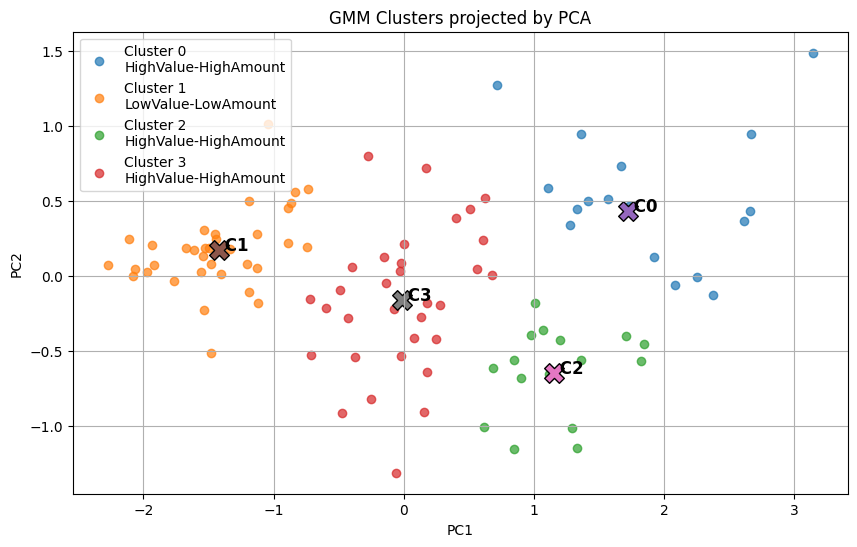

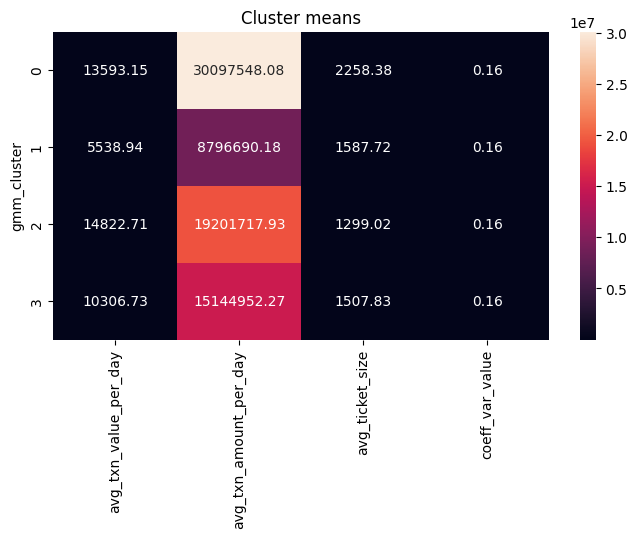

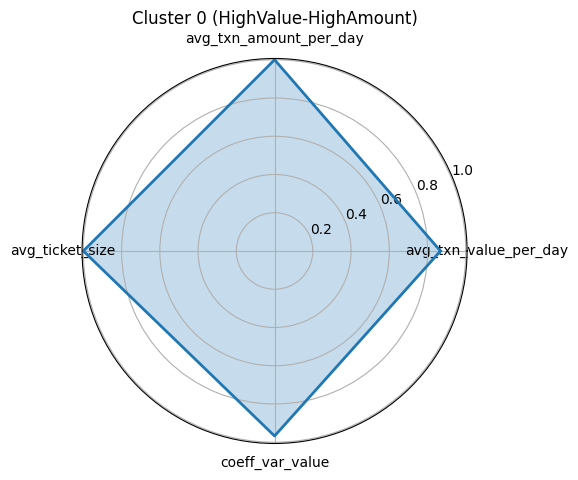

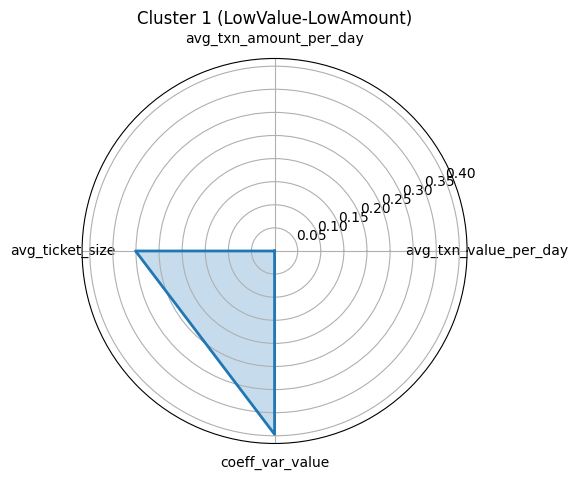

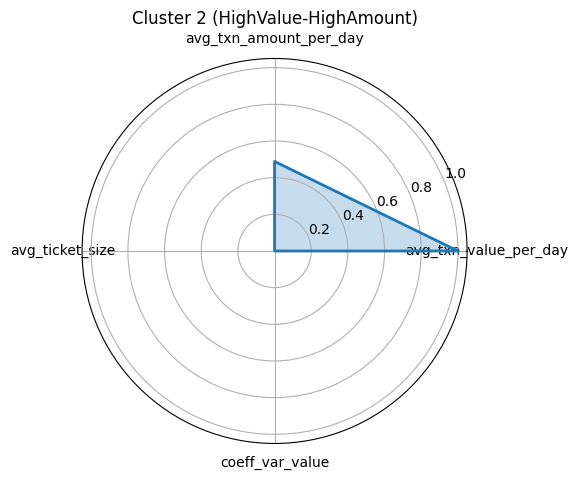

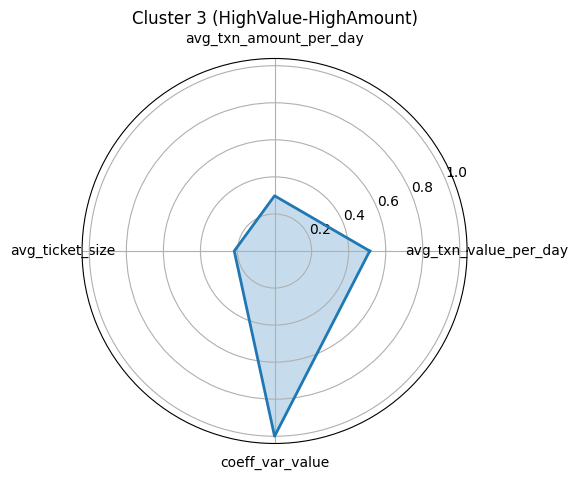

['models_lightgbm_v2\\clustering_artifacts.joblib']

In [20]:
# -----------------------------
# Visualizations: PCA scatter, centers, heatmap, radar
# -----------------------------


pca = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca.fit_transform(X_s)
plt.figure(figsize=(10,6))
for c in sorted(biller_aggs['gmm_cluster'].unique()):
    mask = biller_aggs['gmm_cluster'] == c
    plt.scatter(proj[mask,0], proj[mask,1], label=f'Cluster {c}\n{cluster_label_map[c]}', alpha=0.7)


# plot projected centers
centers_proj = pca.transform(centers_s)
for i,c in enumerate(centers_proj):
    plt.scatter(c[0], c[1], marker='X', s=200, edgecolor='k')
    plt.text(c[0], c[1], f' C{i} ', fontsize=12, fontweight='bold')


plt.legend(); plt.title('GMM Clusters projected by PCA'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.grid(True); plt.show()


# heatmap of cluster means (original scale)
cluster_means = biller_aggs.groupby('gmm_cluster')[features + ['avg_ticket_size','coeff_var_value']].mean()
plt.figure(figsize=(8,4)); sns.heatmap(cluster_means, annot=True, fmt='.2f'); plt.title('Cluster means'); plt.show()


# radar plot per cluster (normalize for display)
from math import pi
radar_feats = ['avg_txn_value_per_day','avg_txn_amount_per_day','avg_ticket_size','coeff_var_value']
clust_stats = biller_aggs.groupby('gmm_cluster')[radar_feats].mean()
clust_stats_norm = (clust_stats - clust_stats.min()) / (clust_stats.max() - clust_stats.min() + 1e-9)


angles = [n / float(len(radar_feats)) * 2 * pi for n in range(len(radar_feats))]
angles += angles[:1]
for cid in clust_stats_norm.index:
    vals = clust_stats_norm.loc[cid].values.tolist()
    vals += vals[:1]
    plt.figure(figsize=(5,5)); ax = plt.subplot(111, polar=True)
    ax.plot(angles, vals, linewidth=2); ax.fill(angles, vals, alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_feats); plt.title(f'Cluster {cid} ({cluster_label_map[cid]})'); plt.show()


# save cluster summary
biller_aggs.to_csv(os.path.join(MODEL_DIR,'biller_clusters_summary.csv'), index=False)
joblib.dump({'gmm':gmm,'scaler':scaler,'cluster_label_map':cluster_label_map}, os.path.join(MODEL_DIR,'clustering_artifacts.joblib'))

In [22]:
# -----------------------------
# Merge cluster labels back to daily and create features
# -----------------------------


daily = df.merge(biller_aggs[['biller_id','gmm_cluster','cluster_label','avg_ticket_size']], on='biller_id', how='left')


daily['day_of_week'] = daily['txn_date'].dt.dayofweek
ndays = (daily['txn_date'].max() - daily['txn_date'].min()).days
print('Total days in data:', ndays)


# create lags and rolling features
lag_days = [1,7,14]
for lag in lag_days:
    daily[f'txn_value_lag_{lag}'] = daily.groupby('biller_id')['txn_value'].shift(lag)
    daily[f'txn_amount_lag_{lag}'] = daily.groupby('biller_id')['txn_amount'].shift(lag)
for w in [7,30]:
    daily[f'txn_value_roll_{w}'] = daily.groupby('biller_id')['txn_value'].shift(1).rolling(w, min_periods=1).mean().reset_index(level=0, drop=True)
    daily[f'txn_amount_roll_{w}'] = daily.groupby('biller_id')['txn_amount'].shift(1).rolling(w, min_periods=1).mean().reset_index(level=0, drop=True)


# fill small NA
daily.fillna(0, inplace=True)


# train/val split by time
split_date = daily['txn_date'].max() - pd.Timedelta(days=TEST_DAYS)
train_daily = daily[daily['txn_date'] <= split_date].copy()
val_daily = daily[daily['txn_date'] > split_date].copy()


# features
feature_cols = ['day_of_week','gmm_cluster','avg_ticket_size'] + [c for c in daily.columns if c.startswith('txn_value_lag_') or c.startswith('txn_value_roll_')]
print('Feature cols count:', len(feature_cols))

Total days in data: 364
Feature cols count: 8


In [25]:
# -----------------------------
# Train LightGBM: txn_value
# -----------------------------
dtrain = lgb.Dataset(train_daily[feature_cols], label=train_daily['txn_value'])
dval = lgb.Dataset(val_daily[feature_cols], label=val_daily['txn_value'])
params = {'objective':'regression','metric':'rmse','verbosity':-1}
model_value = lgb.train(params, dtrain, valid_sets=[dtrain,dval])


# predictions
train_daily['txn_value_pred'] = model_value.predict(train_daily[feature_cols])
val_daily['txn_value_pred'] = model_value.predict(val_daily[feature_cols])

In [26]:
# -----------------------------
# Train LightGBM: txn_amount (use predicted txn_value)
# -----------------------------
train_daily['txn_value_pred_for_amt'] = train_daily['txn_value_pred']
val_daily['txn_value_pred_for_amt'] = val_daily['txn_value_pred']
feature_cols_amt = feature_cols + ['txn_value_pred_for_amt']


dtrain_amt = lgb.Dataset(train_daily[feature_cols_amt], label=train_daily['txn_amount'])
dval_amt = lgb.Dataset(val_daily[feature_cols_amt], label=val_daily['txn_amount'])
model_amount = lgb.train(params, dtrain_amt, valid_sets=[dtrain_amt,dval_amt])


val_daily['txn_amount_pred'] = model_amount.predict(val_daily[feature_cols_amt])


# save models
joblib.dump(model_value, os.path.join(MODEL_DIR,'lgb_txn_value.pkl'))
joblib.dump(model_amount, os.path.join(MODEL_DIR,'lgb_txn_amount.pkl'))

['models_lightgbm_v2\\lgb_txn_amount.pkl']

TXN_VALUE - MAE: 1273.427 RMSE: 1712.065
TXN_AMOUNT - MAE: 2437226.644 RMSE: 3435096.081


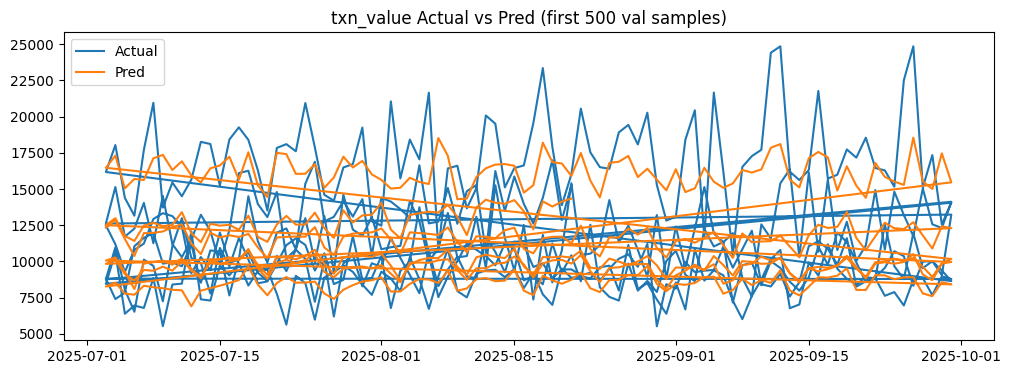

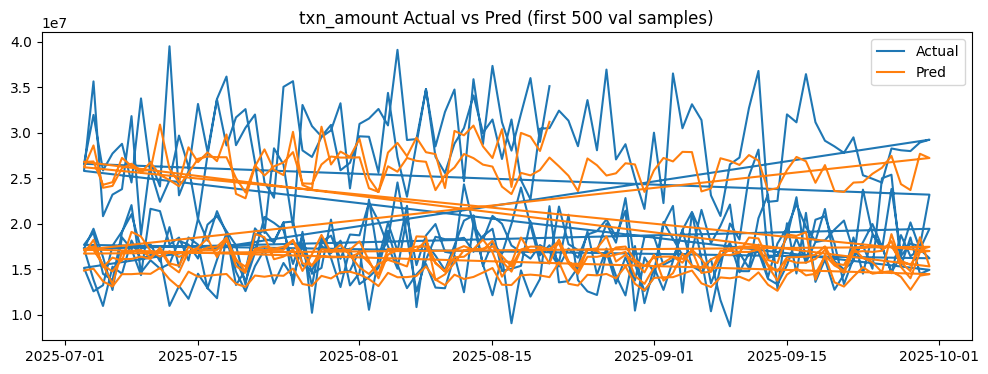

          cluster_label   count    mae_value    mae_amount
0  HighValue-HighAmount  5850.0  1577.993715  3.013165e+06
1    LowValue-LowAmount  3150.0   707.803734  1.367626e+06
LightGBM notebook completed. Artifacts saved to models_lightgbm_v2


In [27]:
from sklearn.metrics import mean_absolute_error


mae_val = mean_absolute_error(val_daily['txn_value'], val_daily['txn_value_pred'])
rmse_val = mean_squared_error(val_daily['txn_value'], val_daily['txn_value_pred'], squared=False)
mae_amt = mean_absolute_error(val_daily['txn_amount'], val_daily['txn_amount_pred'])
rmse_amt = mean_squared_error(val_daily['txn_amount'], val_daily['txn_amount_pred'], squared=False)


print('TXN_VALUE - MAE:', round(mae_val,3), 'RMSE:', round(rmse_val,3))
print('TXN_AMOUNT - MAE:', round(mae_amt,3), 'RMSE:', round(rmse_amt,3))


# Actual vs Predicted sample plots
plt.figure(figsize=(12,4))
plt.plot(val_daily['txn_date'].values[:500], val_daily['txn_value'].values[:500], label='Actual')
plt.plot(val_daily['txn_date'].values[:500], val_daily['txn_value_pred'].values[:500], label='Pred')
plt.legend(); plt.title('txn_value Actual vs Pred (first 500 val samples)'); plt.show()


plt.figure(figsize=(12,4))
plt.plot(val_daily['txn_date'].values[:500], val_daily['txn_amount'].values[:500], label='Actual')
plt.plot(val_daily['txn_date'].values[:500], val_daily['txn_amount_pred'].values[:500], label='Pred')
plt.legend(); plt.title('txn_amount Actual vs Pred (first 500 val samples)'); plt.show()


# time-series per-cluster summary
cluster_perf = val_daily.groupby('cluster_label').apply(lambda x: pd.Series({
'count':len(x),
'mae_value': mean_absolute_error(x['txn_value'], x['txn_value_pred']),
'mae_amount': mean_absolute_error(x['txn_amount'], x['txn_amount_pred'])
})).reset_index()
print(cluster_perf)


print('LightGBM notebook completed. Artifacts saved to', MODEL_DIR)